<a href="https://colab.research.google.com/github/Johnny-DF26/Aplicando_nlp_para_analise_sentimentos/blob/main/NLP_aplicando_processamento_de_linguagem_natural_para_an%C3%A1lise_de_sentimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<font color='red'> NLP: Processamento de linguagem natural para análise de sentimentos**

## **Introdução: O Desafio da Experiência do Cliente**

No cenário atual de e-commerce e serviços digitais, o volume de feedback dos usuários é massivo. Analisar manualmente milhares de avaliações para identificar problemas ou elogios é inviável e caro.

### **O Problema**
Empresas precisam de uma forma escalável e precisa para monitorar a satisfação dos seus clientes. Identificar rapidamente avaliações negativas pode permitir ações de suporte imediatas, enquanto entender os pontos positivos ajuda a reforçar estratégias de marketing.

### **O Objetivo do Projeto**
Este projeto visa desenvolver um sistema de **Análise de Sentimentos** utilizando técnicas avançadas de **Processamento de Linguagem Natural (NLP)**.

Neste notebook, passaremos por todo o pipeline de Ciência de Dados:
1.  **Limpeza e Normalização:** Tratamento de ruídos, acentuação e simplificação de palavras (Stemming).
2.  **Vetorização:** Transformação de texto em dados numéricos usando técnicas clássicas e modernas.
3.  **Modelagem:** Comparação de performance entre modelos lineares e Redes Neurais de última geração (BERTimbau).
4.  **Avaliação:** Análise criteriosa de métricas para garantir que o modelo seja confiável para decisões de negócio.

# **<font color='blue'> 1. Explorando os dados**

## **1.1. Conhecendo os dados**

In [2]:
import pandas as pd

In [3]:
path = 'https://raw.githubusercontent.com/alura-cursos/nlp_analise_sentimento/refs/heads/main/Dados/dataset_avaliacoes.csv'

In [4]:
df = pd.read_csv(path)

In [5]:
print('==='*30)
display(df.head())
print('==='*30)

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [6]:
df.shape

(15501, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15501 entries, 0 to 15500
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID_avaliacao  15501 non-null  int64 
 1   avaliacao     15501 non-null  object
 2   nota          15501 non-null  int64 
 3   sentimento    15501 non-null  object
dtypes: int64(2), object(2)
memory usage: 484.5+ KB


In [8]:
df['sentimento'].value_counts()

,count
sentimento,
positivo,7890
negativo,7611


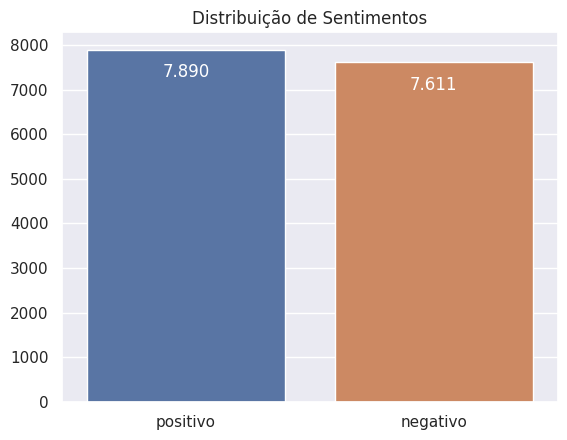

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
sns.countplot(x='sentimento', data=df, hue='sentimento')
plt.title('Distribuição de Sentimentos')
plt.ylabel('')
plt.xlabel('')
#plt.yticks([])

for i, valor in enumerate(df['sentimento'].value_counts()):
    label = f"{valor:,.0f}".replace(',','.')
    plt.text(i, valor-700, label, ha='center', va='bottom', color='white')

plt.show()

In [10]:
print('Avaliação Positiva:\n')

df['avaliacao'][0]

Avaliação Positiva:



'Esse smartphone superou minhas expectativas, recomendo'

In [11]:
print('Avaliação Negativa:\n')
df['avaliacao'][2]

Avaliação Negativa:



'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.'

# **<font color='blue'> 2. Tratamento dos Dados**

## **2.1. Visualizando as palavras mais utilizadas**

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [13]:
# Juntando todas as palavras
all_words = [text for text in df['avaliacao']]
all_words = ' '.join([text for text in df['avaliacao']])
all_words[0:1000]

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

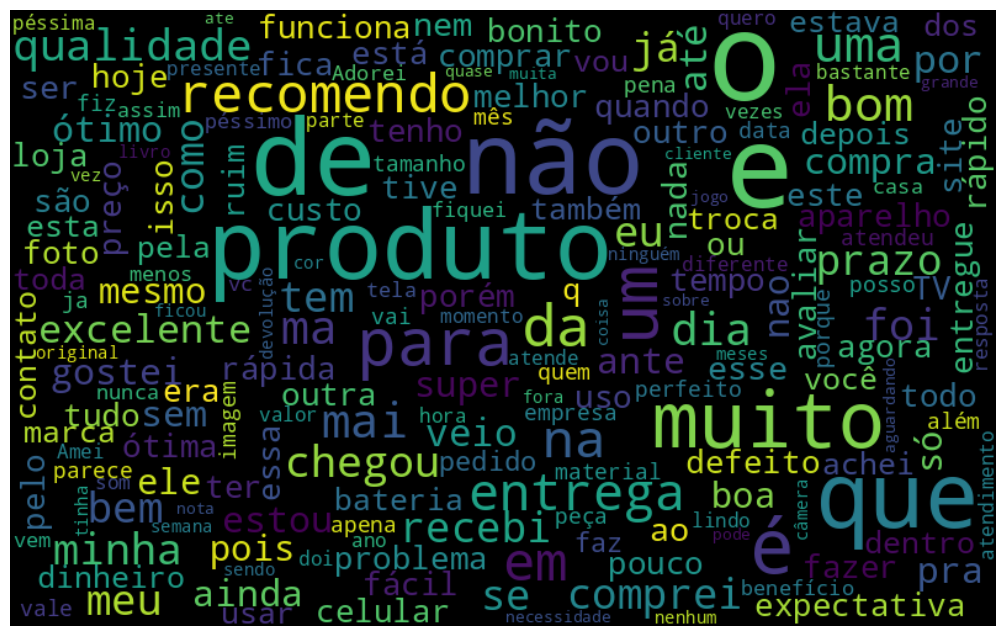

In [14]:
# Rodando a imagem com o rank das palavras
cloud = WordCloud(width=800, height=500, random_state=42, max_font_size=100, collocations=False).generate(all_words)

# Plotagem da figura
plt.figure(figsize=(15,8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [15]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [16]:
avaliacoes_positivas = df.query("sentimento == 'positivo'")['avaliacao']

avaliacoes_positivas.head()

,avaliacao
0,"Esse smartphone superou minhas expectativas, r..."
3,"Atendeu minhas expectativas, só achei a luz ru..."
4,"Gostei muito, só achei que ficou a desejar a q..."
10,"Melhor que esperado, cor maravilhosa! Recomend..."
15,Um aparelho com uma ótima performance e um pre...


In [17]:
avaliacoes_negativas = df.query("sentimento == 'negativo'")['avaliacao']

avaliacoes_negativas.head()

,avaliacao
1,o cheiro e muito desagradavel!! pra quem se in...
2,"Eu fiz a compra a loja não entregou o produto,..."
5,Comprei o produto e ñ tinha para entrega isso ...
6,"o produto pode até ser bom ,mais só posso aval..."
7,"já enviei duas reclamações, mas não obtive res..."


In [18]:
# Juntando todas as palavras
def juntar_palavras(df):
  all_words = [text for text in df]
  all_words = ' '.join([text for text in df])

  return all_words

In [19]:
palavras_positivas = juntar_palavras(avaliacoes_positivas)
palavras_negativas = juntar_palavras(avaliacoes_negativas)

In [20]:
palavras_positivas[0:1000]

'Esse smartphone superou minhas expectativas, recomendo Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Melhor que esperado, cor maravilhosa! Recomendo. Deixa seu ambiente mais moderno Um aparelho com uma ótima performance e um preço bem menor que outros aparelhos de marcas mais conhecidas com performance semelhante. O produto correspondeu as minhas expectativas. Muito bom mesmo! Demorou chega produto, passou ate do prazo, mas celular é bom entrega foi rapido e o mouse e mto bom bonito e tem uma pegada excelente recomendo e o preço ta otimo Produto excelente. É tudo perfeito durante o processo da compra os produtos da linha tramontina são sempre bons, a mesa de passar roupa e otima. A FURADEIRA É MUITO BOA, ATENDE MUITO BEM A EXPECTATIVA, TANTO PARA PARAFUSAR COMO PARA PERFURAR. ÓTIMO. Ótima bicicleta , minha sobrinha amou... chegou na data prevista

In [21]:
palavras_negativas[0:1000]

'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancelamento da compra. A partir de 2017 os jogos online passaram a apresentar problemas como desconexão constante não computando o placar do jogo, um dos times invisível forçando abandono da partida... pelo valor que cobram de anuidade na live e pe

In [22]:
# Rodando a imagem com o rank das palavras Positivas
def rank_palavras(dataframe, avaliacao):
    df = dataframe.query(f"sentimento == '{avaliacao}'")['avaliacao']
    palavras_juntas = juntar_palavras(df)

    cloud = WordCloud(width=800, height=500, random_state=42, max_font_size=100, collocations=False).generate(palavras_juntas)

    # Plotagem da figura
    plt.figure(figsize=(15,8))
    plt.imshow(cloud, interpolation='bilinear')
    plt.title(f'Rank de palavras {avaliacao.title()}')
    plt.axis('off')
    plt.show()

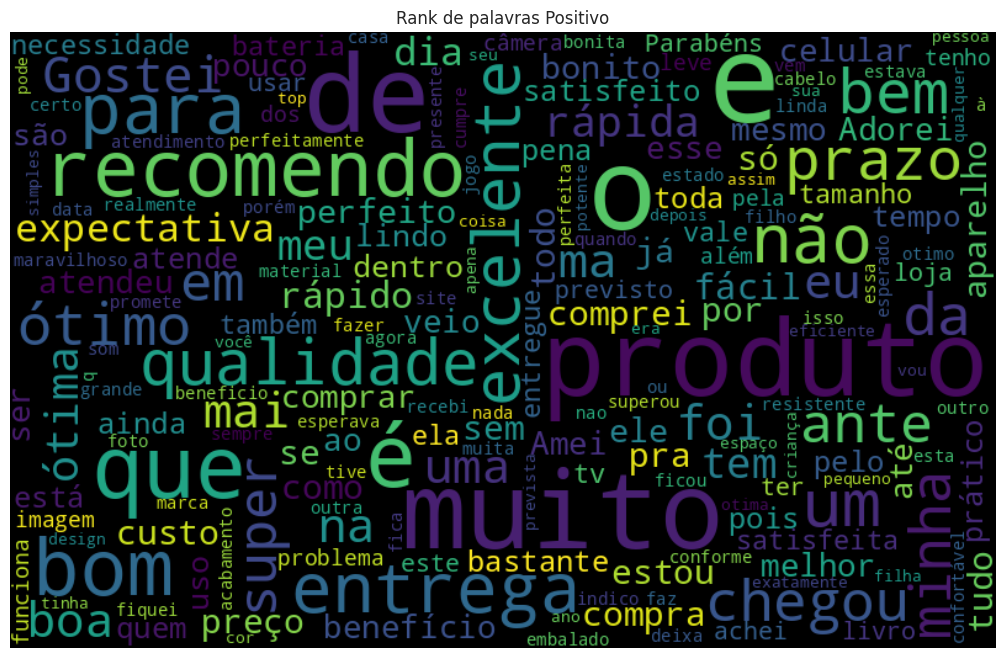

In [23]:
rank_palavras(df, 'positivo')

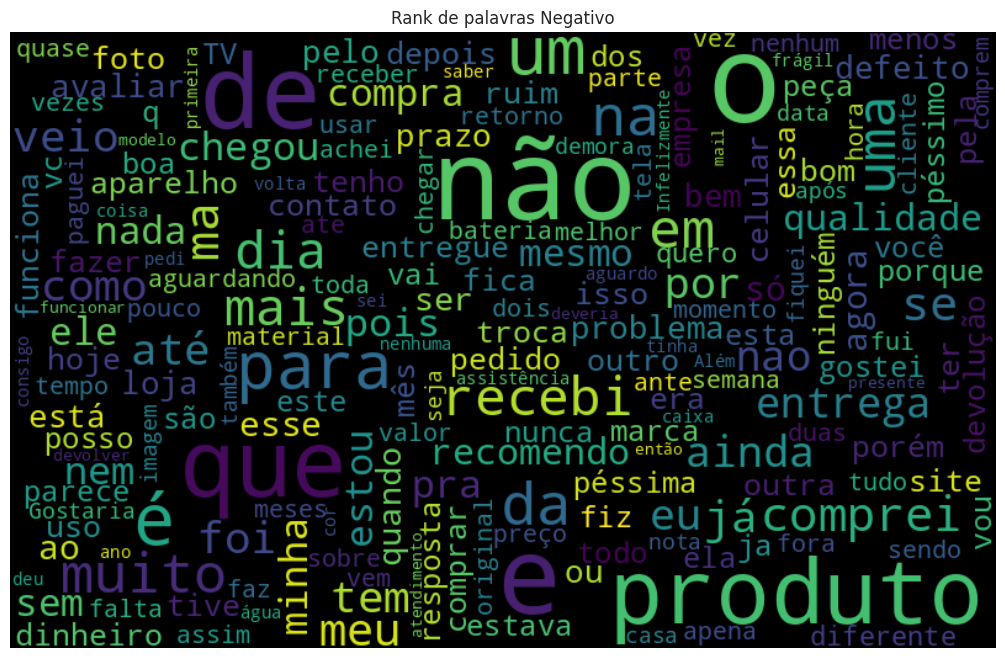

In [24]:
rank_palavras(df, 'negativo')


## **2.2. Limpeza dos dados**

In [25]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [26]:
## Copiando o dataframe
df_normalizado = df.copy()

### **2.2.1. Caixa Baixa**

In [27]:
## Colocando os dados em caixa baixa
df_normalizado['avaliacao_1'] = df_normalizado['avaliacao'].str.lower()

In [28]:
df_normalizado.head()

,ID_avaliacao,avaliacao,nota,sentimento,avaliacao_1
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"esse smartphone superou minhas expectativas, r..."
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"eu fiz a compra a loja não entregou o produto,..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"atendeu minhas expectativas, só achei a luz ru..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"gostei muito, só achei que ficou a desejar a q..."


### **2.2.2. Acentos**

In [29]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.7 MB/s eta 0:00:00


In [30]:
## Tratando as acentuacoes
import unidecode

texto_sem_acentos = [unidecode.unidecode(texto) for texto in df_normalizado['avaliacao_1']]

df_normalizado['avaliacao_2'] = texto_sem_acentos

In [31]:
df_normalizado.head()

,ID_avaliacao,avaliacao,nota,sentimento,avaliacao_1,avaliacao_2
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"esse smartphone superou minhas expectativas, r...","esse smartphone superou minhas expectativas, r..."
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel!! pra quem se in...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"eu fiz a compra a loja não entregou o produto,...","eu fiz a compra a loja nao entregou o produto,..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"atendeu minhas expectativas, só achei a luz ru...","atendeu minhas expectativas, so achei a luz ru..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"gostei muito, só achei que ficou a desejar a q...","gostei muito, so achei que ficou a desejar a q..."


### **2.2.3. Pontuação**

In [32]:
from nltk import tokenize

In [33]:
## Retirando pontuações
token_pontuacao = tokenize.WordPunctTokenizer() ## Separa pelas pontuacoes

palavras_pontuacao = []

for pal in df_normalizado['avaliacao_2']:
    texto_tokenizado = token_pontuacao.tokenize(pal)
    nova_frase = [palavra for palavra in texto_tokenizado if palavra.isalpha()]
    palavras_pontuacao.append(' '.join(nova_frase))

df_normalizado['avaliacao_3'] = palavras_pontuacao

In [34]:
df_normalizado.head()

,ID_avaliacao,avaliacao,nota,sentimento,avaliacao_1,avaliacao_2,avaliacao_3
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"esse smartphone superou minhas expectativas, r...","esse smartphone superou minhas expectativas, r...",esse smartphone superou minhas expectativas re...
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel pra quem se inco...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"eu fiz a compra a loja não entregou o produto,...","eu fiz a compra a loja nao entregou o produto,...",eu fiz a compra a loja nao entregou o produto ...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"atendeu minhas expectativas, só achei a luz ru...","atendeu minhas expectativas, so achei a luz ru...",atendeu minhas expectativas so achei a luz rui...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"gostei muito, só achei que ficou a desejar a q...","gostei muito, so achei que ficou a desejar a q...",gostei muito so achei que ficou a desejar a qu...


### **2.2.4. Stop Words**

In [35]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [36]:
## Retirando as StopWords

palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')

In [37]:
## Aplicando Stop Words
from nltk import tokenize

palavras_stop_words = []

stop_word = tokenize.WhitespaceTokenizer()

for palavra in df_normalizado['avaliacao_3']:
    palavras_tokenizadas = stop_word.tokenize(palavra)
    palavras_sem_irrelevantes = [palavra for palavra in palavras_tokenizadas if palavra not in palavras_irrelevantes]
    palavras_stop_words.append(' '.join(palavras_sem_irrelevantes))

df_normalizado['avaliacao_4'] = palavras_stop_words

In [38]:
df_normalizado.head()

,ID_avaliacao,avaliacao,nota,sentimento,avaliacao_1,avaliacao_2,avaliacao_3,avaliacao_4
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"esse smartphone superou minhas expectativas, r...","esse smartphone superou minhas expectativas, r...",esse smartphone superou minhas expectativas re...,smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel pra quem se inco...,cheiro desagradavel pra incomoda nao recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"eu fiz a compra a loja não entregou o produto,...","eu fiz a compra a loja nao entregou o produto,...",eu fiz a compra a loja nao entregou o produto ...,fiz compra loja nao entregou produto compra fe...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"atendeu minhas expectativas, só achei a luz ru...","atendeu minhas expectativas, so achei a luz ru...",atendeu minhas expectativas so achei a luz rui...,atendeu expectativas so achei luz ruim nada di...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"gostei muito, só achei que ficou a desejar a q...","gostei muito, so achei que ficou a desejar a q...",gostei muito so achei que ficou a desejar a qu...,gostei so achei ficou desejar qualidade fotos ...


In [39]:
df_normalizado['avaliacao'][3]

'Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.'

In [40]:
df_normalizado['avaliacao_4'][3]

'atendeu expectativas so achei luz ruim nada dificulte funcionamento'

In [41]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

def classificar_texto(texto, coluna_texto, coluna_classificacao):

    print(f"Treinando e avaliando Modelo {coluna_texto.split('_')[1]} ...")
    # Vetorizando os dados
    vetorizar = CountVectorizer(max_features=50)
    X = vetorizar.fit_transform(texto[coluna_texto])
    y = texto[coluna_classificacao]

    print(f"Shape: {X.shape}")
    # Pré-processando em números
    encoder = LabelEncoder()
    y = encoder.fit_transform(y)

    # Divisão em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4978)

    # Treinando o modelo
    rl = LogisticRegression(max_iter=1000)
    rl.fit(X_train, y_train)

    # Avaliando o desempenho do modelo
    acuracia = rl.score(X_test, y_test)


    return print(f"Acurácia do modelo com {coluna_texto}: {acuracia:.2f}")

In [42]:
classificar_texto(df_normalizado, 'avaliacao_1', 'sentimento')

Treinando e avaliando Modelo 1 ...
Shape: (15501, 50)
Acurácia do modelo com avaliacao_1: 0.84


In [43]:
classificar_texto(df_normalizado, 'avaliacao_2', 'sentimento')

Treinando e avaliando Modelo 2 ...
Shape: (15501, 50)
Acurácia do modelo com avaliacao_2: 0.84


In [44]:
classificar_texto(df_normalizado, 'avaliacao_3', 'sentimento')

Treinando e avaliando Modelo 3 ...
Shape: (15501, 50)
Acurácia do modelo com avaliacao_3: 0.84


In [45]:
classificar_texto(df_normalizado, 'avaliacao_4', 'sentimento')

Treinando e avaliando Modelo 4 ...
Shape: (15501, 50)
Acurácia do modelo com avaliacao_4: 0.86


### **2.2.5. Simplificação de Palavras**

In [46]:
nltk.download('rslp')

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


True

In [47]:
stemmer  = nltk.RSLPStemmer()

stemmer.stem('gostou')

'gost'

In [48]:
frase_processada = []

for text in df_normalizado['avaliacao_4']:
    palavras_texto = token_pontuacao.tokenize(text)
    nova_frase = [stemmer.stem(palavra) for palavra in palavras_texto]
    frase_processada.append(' '.join(nova_frase))


In [49]:
df_normalizado['avaliacao_5'] = frase_processada

In [50]:
df_normalizado.head()

,ID_avaliacao,avaliacao,nota,sentimento,avaliacao_1,avaliacao_2,avaliacao_3,avaliacao_4,avaliacao_5
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"esse smartphone superou minhas expectativas, r...","esse smartphone superou minhas expectativas, r...",esse smartphone superou minhas expectativas re...,smartphone superou expectativas recomendo,smartphon super expect recom
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel pra quem se inco...,cheiro desagradavel pra incomoda nao recomendoo,cheir desagrada pra incomod nao recomendo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"eu fiz a compra a loja não entregou o produto,...","eu fiz a compra a loja nao entregou o produto,...",eu fiz a compra a loja nao entregou o produto ...,fiz compra loja nao entregou produto compra fe...,fiz compr loj nao entreg produt compr feit car...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"atendeu minhas expectativas, só achei a luz ru...","atendeu minhas expectativas, so achei a luz ru...",atendeu minhas expectativas so achei a luz rui...,atendeu expectativas so achei luz ruim nada di...,atend expect so ach luz ruim nad dificult funcion
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"gostei muito, só achei que ficou a desejar a q...","gostei muito, so achei que ficou a desejar a q...",gostei muito so achei que ficou a desejar a qu...,gostei so achei ficou desejar qualidade fotos ...,gost so ach fic desej qual fot ach bem melhor


In [51]:
classificar_texto(df_normalizado, 'avaliacao_5', 'sentimento')

Treinando e avaliando Modelo 5 ...
Shape: (15501, 50)
Acurácia do modelo com avaliacao_5: 0.88


### **2.2.6. Aplicação de Contexto**

In [52]:
from nltk import ngrams
from nltk import tokenize

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [54]:
texto_exemplo = 'Eu não gostei do produto, pois veio com defeito.'

token_tokenizer = tokenize.WordPunctTokenizer()
frase_token = token_tokenizer.tokenize(texto_exemplo)
pares = list(ngrams(frase_token, 3))

print(pares)

[('Eu', 'não', 'gostei'), ('não', 'gostei', 'do'), ('gostei', 'do', 'produto'), ('do', 'produto', ','), ('produto', ',', 'pois'), (',', 'pois', 'veio'), ('pois', 'veio', 'com'), ('veio', 'com', 'defeito'), ('com', 'defeito', '.')]


In [55]:
texto_exemplo = 'Eu não gostei do produto, pois veio com defeito.'
tf_idf = TfidfVectorizer(max_features=50, sublinear_tf=True, ngram_range=(1,3))

tf_vetorizado = tf_idf.fit_transform([texto_exemplo])

### **2.2.7. Salvando DataFrame**

In [56]:
## Salvando dataframe

df_normalizado.to_csv('/content/drive/MyDrive/CSVs/df_nlp_sentimentos.csv', index=False)

# **<font color='blue'> 3. Aplicando o Algoritmos de NLP**

## **Buscando Base de dados salva**

In [57]:
import pandas as pd

In [58]:
df_normalizado = pd.read_csv('/content/drive/MyDrive/CSVs/df_nlp_sentimentos.csv')

## **3.1. Divisão em treino e teste**

In [59]:
df_normalizado.head()

,ID_avaliacao,avaliacao,nota,sentimento,avaliacao_1,avaliacao_2,avaliacao_3,avaliacao_4,avaliacao_5
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"esse smartphone superou minhas expectativas, r...","esse smartphone superou minhas expectativas, r...",esse smartphone superou minhas expectativas re...,smartphone superou expectativas recomendo,smartphon super expect recom
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel pra quem se inco...,cheiro desagradavel pra incomoda nao recomendoo,cheir desagrada pra incomod nao recomendo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"eu fiz a compra a loja não entregou o produto,...","eu fiz a compra a loja nao entregou o produto,...",eu fiz a compra a loja nao entregou o produto ...,fiz compra loja nao entregou produto compra fe...,fiz compr loj nao entreg produt compr feit car...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"atendeu minhas expectativas, só achei a luz ru...","atendeu minhas expectativas, so achei a luz ru...",atendeu minhas expectativas so achei a luz rui...,atendeu expectativas so achei luz ruim nada di...,atend expect so ach luz ruim nad dificult funcion
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"gostei muito, só achei que ficou a desejar a q...","gostei muito, so achei que ficou a desejar a q...",gostei muito so achei que ficou a desejar a qu...,gostei so achei ficou desejar qualidade fotos ...,gost so ach fic desej qual fot ach bem melhor


In [60]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_encoder = encoder.fit_transform(df_normalizado['sentimento'])
df_normalizado['sentimento_encoder'] = df_encoder

In [61]:
df_normalizado

,ID_avaliacao,avaliacao,nota,sentimento,avaliacao_1,avaliacao_2,avaliacao_3,avaliacao_4,avaliacao_5,sentimento_encoder
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"esse smartphone superou minhas expectativas, r...","esse smartphone superou minhas expectativas, r...",esse smartphone superou minhas expectativas re...,smartphone superou expectativas recomendo,smartphon super expect recom,1
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel!! pra quem se in...,o cheiro e muito desagradavel pra quem se inco...,cheiro desagradavel pra incomoda nao recomendoo,cheir desagrada pra incomod nao recomendo,0
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"eu fiz a compra a loja não entregou o produto,...","eu fiz a compra a loja nao entregou o produto,...",eu fiz a compra a loja nao entregou o produto ...,fiz compra loja nao entregou produto compra fe...,fiz compr loj nao entreg produt compr feit car...,0
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"atendeu minhas expectativas, só achei a luz ru...","atendeu minhas expectativas, so achei a luz ru...",atendeu minhas expectativas so achei a luz rui...,atendeu expectativas so achei luz ruim nada di...,atend expect so ach luz ruim nad dificult funcion,1
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"gostei muito, só achei que ficou a desejar a q...","gostei muito, so achei que ficou a desejar a q...",gostei muito so achei que ficou a desejar a qu...,gostei so achei ficou desejar qualidade fotos ...,gost so ach fic desej qual fot ach bem melhor,1
...,...,...,...,...,...,...,...,...,...,...
15496,61836,Bommm.mmmmmmmmmmmmmmmm Mmmmmmmmmmmmmmmmmmmmmmm...,4,positivo,bommm.mmmmmmmmmmmmmmmm mmmmmmmmmmmmmmmmmmmmmmm...,bommm.mmmmmmmmmmmmmmmm mmmmmmmmmmmmmmmmmmmmmmm...,bommm mmmmmmmmmmmmmmmm mmmmmmmmmmmmmmmmmmmmmmm...,bommm mmmmmmmmmmmmmmmm mmmmmmmmmmmmmmmmmmmmmmm...,bommm mmmmmmmmmmmmmmmm mmmmmmmmmmmmmmmmmmmmmmm...,1
15497,19503,"O produto seca o cabelo, mas tem que passar di...",2,negativo,"o produto seca o cabelo, mas tem que passar di...","o produto seca o cabelo, mas tem que passar di...",o produto seca o cabelo mas tem que passar div...,produto seca cabelo passar diversas vezes mesm...,produt sec cabel pass divers vez mesm mech,0
15498,52712,"Muito simples de mexer, o manual explica direi...",5,positivo,"muito simples de mexer, o manual explica direi...","muito simples de mexer, o manual explica direi...",muito simples de mexer o manual explica direit...,simples mexer manual explica direitinho funcio...,simpl mex man explic direit funcion produt mim...,1
15499,10874,"Produto muito bom, exatamente como na internet...",4,positivo,"produto muito bom, exatamente como na internet...","produto muito bom, exatamente como na internet...",produto muito bom exatamente como na internet ...,produto bom exatamente internet chegou antes p...,produt bom exat internet cheg ant praz,1


In [62]:
df_normalizado.isnull().sum()


,0
ID_avaliacao,0
avaliacao,0
nota,0
sentimento,0
avaliacao_1,0
avaliacao_2,0
avaliacao_3,16
avaliacao_4,16
avaliacao_5,16
sentimento_encoder,0


In [68]:
df_normalizado.dropna(inplace=True)

In [69]:
df_normalizado.isnull().sum()


,0
ID_avaliacao,0
avaliacao,0
nota,0
sentimento,0
avaliacao_1,0
avaliacao_2,0
avaliacao_3,0
avaliacao_4,0
avaliacao_5,0
sentimento_encoder,0


In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(df_normalizado['avaliacao_5'], df_normalizado['sentimento_encoder'], test_size=0.2, random_state=42)

In [72]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12388,), (3097,), (12388,), (3097,))

## **3.2. Bag of Words**

### 📝 Técnica 1: Bag of Words (Saco de Palavras)

O **Bag of Words (BoW)** é uma das técnicas mais clássicas e diretas para converter texto em números. A intuição por trás do método é exatamente o que o nome sugere: o modelo pega todas as palavras do texto, "joga dentro de um saco" e descarta totalmente a estrutura gramatical, a ordem das frases e o contexto. O que importa para o algoritmo é apenas a **presença e a frequência** das palavras.

#### ⚙️ Como funciona o fluxo técnico:
1. **Vocabulário Global:** O algoritmo varre todo o conjunto de texto de treino e cria um dicionário com todas as palavras únicas encontradas.
2. **Criação de Colunas:** Cada palavra desse dicionário vira uma coluna em nossa matriz de features ($X$).
3. **Vetorização (Contagem):** Para cada avaliação, o modelo preenche as colunas contando quantas vezes aquela palavra específica apareceu na frase.

#### 📊 Exemplo Prático:
Se tivéssemos apenas duas avaliações na base de dados:
* *Avaliação 1:* `"Ótimo produto, ótimo prazo."`
* *Avaliação 2:* `"Produto ruim."`

O resultado que o modelo de Machine Learning recebe é uma tabela numérica parecida com esta:


| Avaliação | ótimo | produto | prazo | ruim |
| :--- | :---: | :---: | :---: | :---: |
| **Avaliação 1** | 2 | 1 | 1 | 0 |
| **Avaliação 2** | 0 | 1 | 0 | 1 |

#### ⚖️ Prós e Contras da Técnica:
* **Vantagens:** Extremamente simples de entender, rápida de computar e muito eficiente para identificar palavras de forte impacto (como "excelente" para positivo ou "horroroso" para negativo).
* **Limitações (O Ponto Cego):** Não entende contexto ou negações. Para o Bag of Words, as frases *"O produto é bom, não é ruim"* e *"O produto é ruim, não é bom"* geram exatamente os mesmos números para o saco, apesar de terem sentimentos completamente opostos.


### **3.2.1. Vetorização**

In [73]:
from sklearn.feature_extraction.text import CountVectorizer
import scipy.sparse as sp

In [74]:
# Vetorizar apenas o texto da avaliação
print("--- Executando TÉCNICA 1: Bag of Words + Nota Numérica ---")

bow_vectorizer = CountVectorizer(max_features=50)
X_train_vector = bow_vectorizer.fit_transform(X_train)
X_test_vector = bow_vectorizer.transform(X_test)

--- Executando TÉCNICA 1: Bag of Words + Nota Numérica ---


In [75]:
X_train_vector.shape

(12388, 50)

### **3.2.2. Treinando o modelo**

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [77]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vector, y_train)

LogisticRegression(max_iter=1000)

In [78]:
predicoes_bag_lr = lr.predict(X_test_vector)

### **3.2.3. Avaliação**

In [79]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, confusion_matrix


Acurácia Geral: 0.8802
------------------------------------------------------------

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1492
           1       0.90      0.87      0.88      1605

    accuracy                           0.88      3097
   macro avg       0.88      0.88      0.88      3097
weighted avg       0.88      0.88      0.88      3097

------------------------------------------------------------


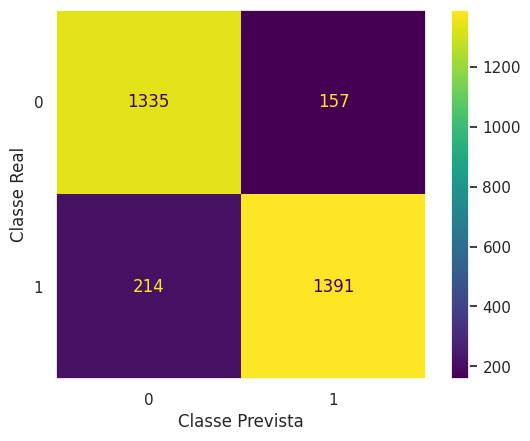

In [80]:
# 📊 MÉTRICAS E RESULTADOS Logistic Regression
# ==========================================
import matplotlib.pyplot as plt

print(f"\nAcurácia Geral: {accuracy_score(y_test, predicoes_bag_lr):.4f}")
print('---'*20)
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, predicoes_bag_lr))
print('---'*20)
ConfusionMatrixDisplay.from_estimator(lr, X_test_vector, y_test)
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.grid(False)
plt.show()

## **3.3. TF-IDF (Term Frequency-Inverse Document Frequency)**

### 📊 Técnica 2: TF-IDF (Term Frequency-Inverse Document Frequency)

O **TF-IDF** é uma evolução matemática direta do Bag of Words. Enquanto o método anterior apenas conta a frequência absoluta das palavras, o TF-IDF calcula a **relevância e a importância real** de cada palavra dentro do seu conjunto de dados. Ele foi desenhado para resolver o problema de palavras muito comuns que não agregam valor à classificação.

#### ⚙️ Como funciona a fórmula matemática:
O TF-IDF é o resultado da multiplicação de dois componentes principais:
1. **TF (Term Frequency / Frequência do Termo):** Mede quão frequente uma palavra é em uma avaliação específica. Se a palavra aparece muito naquela linha, o TF aumenta.
2. **IDF (Inverse Document Frequency / Frequência Inversa nos Documentos):** Mede quão rara a palavra é ao olhar para a base inteira. Palavras que aparecem em quase todas as avaliações (como "o", "a", "produto", "que") recebem um peso IDF próximo de **zero**. Palavras raras e expressivas (como "excelente", "defeito", "maravilhoso") ganham um peso IDF **alto**.

#### ⚖️ Prós e Contras da Técnica:
* **Vantagens:** Consegue filtrar automaticamente o ruído do texto sem a necessidade obrigatória de uma lista gigante de *stop words*. Dá pesos muito precisos para termos que definem o sentimento (positivos ou negativos), sendo o algoritmo clássico de melhor custo-benefício em PLN.
* **Limitações:** Assim como o Bag of Words, o TF-IDF padrão ainda trata as palavras de forma isolada. Ele falha em capturar a ordem exata da frase, o contexto semântico profundo e nuances complexas como o sarcasmo.


### **3.3.1. Vetorização**

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [82]:
print("--- Executando TÉCNICA 2: TF-IDF APENAS com Texto (Sem Nota) ---")

# Inicializar o vetorizador TF-IDF
# max_features=5000 limita o vocabulário para evitar lentidão
# sublinear_tf=True aplica escala logarítmica à frequência das palavras, o que melhora o desempenho
tfidf_vectorizer = TfidfVectorizer(max_features=1000, sublinear_tf=True, ngram_range=(1,3))

# Transformar os textos de treino e teste
X_train_tf = tfidf_vectorizer.fit_transform(X_train)
X_test_tf = tfidf_vectorizer.transform(X_test)

print("--- Execução Finalizada ... ---")

--- Executando TÉCNICA 2: TF-IDF APENAS com Texto (Sem Nota) ---
--- Execução Finalizada ... ---


### **3.3.2. Treinando os dados**

In [83]:
from sklearn.linear_model import LogisticRegression

In [84]:
lr_tf = LogisticRegression(max_iter=1000)
lr_tf.fit(X_train_tf, y_train)

LogisticRegression(max_iter=1000)

In [85]:
previsao_lr_tf = lr_tf.predict(X_test_tf)

### **3.3.3. Avaliando o Modelo**

In [86]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, confusion_matrix


Acurácia Geral: 0.9306
------------------------------------------------------------

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1492
           1       0.95      0.92      0.93      1605

    accuracy                           0.93      3097
   macro avg       0.93      0.93      0.93      3097
weighted avg       0.93      0.93      0.93      3097

------------------------------------------------------------


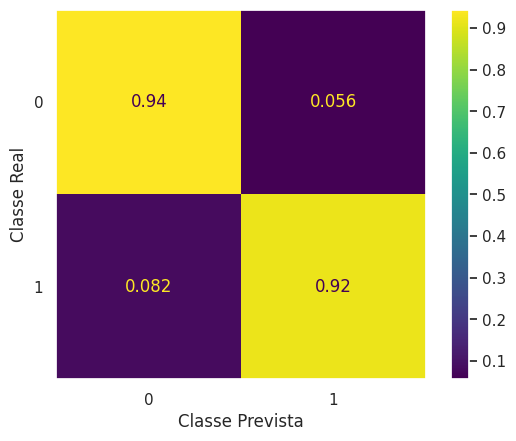

In [87]:
# 📊 MÉTRICAS E RESULTADOS Logistic Regression
# ==========================================
import matplotlib.pyplot as plt

print(f"\nAcurácia Geral: {accuracy_score(y_test, previsao_lr_tf):.4f}")
print('---'*20)
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, previsao_lr_tf))
print('---'*20)
ConfusionMatrixDisplay.from_estimator(lr_tf, X_test_tf, y_test, normalize='true')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.grid(False)
plt.show()

### **3.3.4. Validação Cruzada**

In [88]:
from sklearn.model_selection import cross_val_score, KFold

In [89]:
## Validação Cruzada
from sklearn.model_selection import cross_val_score, KFold

def validacao_cruzada(n_splits=5, cv=5):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(lr_tf, X_train_tf, y_train, cv=cv)
    return scores

In [90]:
# Intervalo de Confiança
from scipy.stats import sem, t
import numpy as np

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data)
    h = std_err * t.ppf((1 + confidence) / 2, n - 1)
    ic_inferior = mean - h
    ic_superior = mean + h

    print(f"Média: {mean:.4f}\
            Desvio Padrão: {std_err:.4f}\
            Intervalo Confiança: [{ic_inferior:.4f} ~ {ic_superior:.4f}]")

In [91]:
scores_5 = validacao_cruzada(n_splits=5, cv=5)
print(f"Resultados:\n{scores_5}")
confidence_interval(scores_5, confidence=0.95)

Resultados:
[0.93301049 0.9346247  0.92937853 0.93338716 0.91844974]
Média: 0.9298            Desvio Padrão: 0.0059            Intervalo Confiança: [0.9133 ~ 0.9462]


In [92]:
scores_10 = validacao_cruzada(n_splits=10, cv=10)
print(f"Resultados:\n{scores_10}")
confidence_interval(scores_10, confidence=0.95)

Resultados:
[0.94108152 0.92816788 0.94188862 0.92736077 0.93139629 0.93058918
 0.9346247  0.9362389  0.91922456 0.91760905]
Média: 0.9308            Desvio Padrão: 0.0077            Intervalo Confiança: [0.9133 ~ 0.9483]


In [93]:
scores_30 = validacao_cruzada(n_splits=30, cv=30)
print(f"Resultados:\n{scores_30}")
confidence_interval(scores_30, confidence=0.95)

Resultados:
[0.95399516 0.9346247  0.9346247  0.93220339 0.9346247  0.92009685
 0.95641646 0.92978208 0.937046   0.93946731 0.92978208 0.91041162
 0.92251816 0.94430993 0.92009685 0.93946731 0.91041162 0.9346247
 0.94915254 0.92251816 0.93946731 0.93220339 0.94188862 0.937046
 0.92251816 0.92009685 0.92251816 0.91283293 0.9223301  0.91747573]
Média: 0.9308            Desvio Padrão: 0.0119            Intervalo Confiança: [0.9065 ~ 0.9551]


#### **Análise Técnica da Validação Cruzada**

A validação cruzada (K-Fold) nos permite avaliar a **consistência** do modelo em diferentes partes do dataset.

**O que os resultados nos dizem?**
*   **Estabilidade:** Com uma média de acurácia em torno de **93%** e um desvio padrão baixo, o modelo mostra que não sofre de *overfitting* severo e que o desempenho é estável independente da fatia de dados utilizada.
*   **Intervalo de Confiança:** O intervalo calculado (ex: [91.3% ~ 94.8%]) nos dá a segurança estatística de que, ao receber novos dados similares em produção, a acurácia do modelo provavelmente se manterá dentro desta faixa.
*   **Confiabilidade de Negócio:** Isso demonstra que é uma solução robusta. Se o desvio padrão fosse muito alto, saberíamos que o modelo é instável e dependente de exemplos específicos.

### **3.3.5. Salvando o modelo**

In [94]:
import joblib
joblib.dump(lr_tf, '/content/drive/MyDrive/models-pkl/model_logistic_regressor_nlp_sentimentos.pkl')
joblib.dump(tfidf_vectorizer, '/content/drive/MyDrive/models-pkl/tfidf_vectorizer_nlp_sentimentos.pkl')

['/content/drive/MyDrive/models-pkl/tfidf_vectorizer_nlp_sentimentos.pkl']

## **3.4. Word Embeddings (Word2Vec)**

### 🌐 Técnica 3: Word Embeddings (Word2Vec / GloVe)

Os **Word Embeddings** representam uma mudança de paradigma em relação às abordagens estatísticas anteriores (BoW e TF-IDF). Em vez de tratar as palavras como chaves isoladas em uma tabela, esta técnica mapeia cada palavra para um espaço vetorial contínuo (geralmente de 100 a 300 dimensões).

A grande sacada matemática aqui é que **palavras que aparecem em contextos semelhantes possuem vetores semelhantes**.

#### ⚙️ Como funciona a inteligência da frase:
1. **Significado Geométrico:** No Word2Vec, a distância entre vetores reflete a proximidade de significado. O modelo entende equações conceituais como: $Vetor(Rei) - Vetor(Homem) + Vetor(Mulher) \approx Vetor(Rainha)$.
2. **Vetorização da Frase:** Para classificar uma avaliação inteira, o código extrai o vetor de cada palavra isolada do comentário e calcula o **Vetor Médio** do texto, gerando um mapa consolidado do assunto para o classificador.

#### ⚖️ Prós e Contras da Técnica:
* **Vantagens:** O modelo passa a compreender sinônimos. Se ele aprender no treino que a palavra "péssimo" indica uma insatisfação, ele automaticamente associará a palavra "horrendo" ao mesmo sentimento no teste, mesmo que ela nunca tenha aparecido nos dados de treino.
* **Limitações:** A média simples dos vetores achata o texto e pode perder o foco principal. Além disso, os embeddings tradicionais são **estáticos**: a palavra "banco" terá exatamente o mesmo vetor numérico se a frase for "sentei no banco da praça" ou "paguei o boleto no banco".


### **3.4.1. Bibliotecas**

In [95]:
!pip install spacy
!python -m spacy download pt_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 16.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### **3.4.2. Vetorização**

In [96]:
import numpy as np
import spacy

In [97]:
print("--- Executando TÉCNICA 3: Word Embeddings (Conceito Word2Vec) ---")

# 1. Carregar o modelo de linguagem em português com suporte a vetores (embeddings)
nlp = spacy.load("pt_core_news_md")

--- Executando TÉCNICA 3: Word Embeddings (Conceito Word2Vec) ---


In [98]:
# 2. Função para transformar um texto completo em um vetor numérico médio
# O Spacy faz exatamente o papel do Word2Vec: calcula a média dos vetores de cada palavra da frase
def extrair_vetor_medio(textos):
    vetores = []
    for doc in nlp.pipe(textos, disable=["ner", "parser"]):
        # doc.vector extrai a média geométrica dos embeddings de todas as palavras da avaliação
        vetores.append(doc.vector)
    return np.array(vetores)

In [99]:
# 3. Converter os textos de treino e teste em matrizes de vetores (embeddings)
print("Convertendo os textos de treino em vetores...")
X_train_w2v = extrair_vetor_medio(X_train)

Convertendo os textos de treino em vetores...


In [100]:
print("Convertendo os textos de teste em vetores...")
X_test_w2v = extrair_vetor_medio(X_test)

Convertendo os textos de teste em vetores...


### **3.4.3. Treinando o modelo**

In [101]:
lr_we = LogisticRegression(max_iter=1000)

lr_we.fit(X_train_w2v, y_train)

LogisticRegression(max_iter=1000)

In [102]:
previsao_we = lr_we.predict(X_test_w2v)

### **3.4.4. Avaliação**


Acurácia Geral: 0.8915


Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1492
           1       0.91      0.87      0.89      1605

    accuracy                           0.89      3097
   macro avg       0.89      0.89      0.89      3097
weighted avg       0.89      0.89      0.89      3097



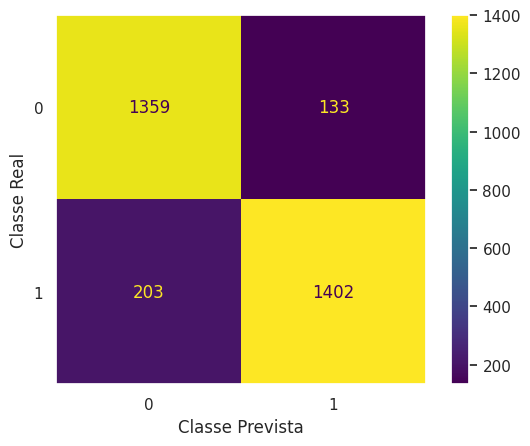

In [103]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, confusion_matrix

print(f"\nAcurácia Geral: {accuracy_score(y_test, previsao_we):.4f}\n")
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, previsao_we))
ConfusionMatrixDisplay.from_estimator(lr_we, X_test_w2v, y_test)
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.grid(False)
plt.show()

## **3.5. Transformers (BERTimbau)**

Em vez de tirar uma média matemática burra das palavras, os Transformers usam o mecanismo de Atenção. O BERT lê a frase inteira e consegue entender que a palavra "defeito" é o núcleo principal da avaliação, dando um peso gigantesco para ela no vetor final ([CLS]).

### 🤖 Técnica 4: Modelos Baseados em Transformers (BERTimbau)

Os **Transformers** representam o estado da arte absoluto em Processamento de Linguagem Natural (PLN) e são o motor tecnológico por trás dos sistemas de busca modernos, LLMs (como GPT e Claude) e mecanismos de **RAG**. Nesta etapa, utilizamos o **BERTimbau**, um modelo BERT pré-treinado massivamente com textos em português do Brasil [1].

#### ⚙️ Como funciona a revolução da Atenção Contextual:
1. **Embeddings Dinâmicos:** Ao contrário do Word2Vec, o BERT gera números diferentes para a mesma palavra dependendo do contexto. Ele analisa a frase inteira simultaneamente por meio do mecanismo de *Self-Attention*, capturando dependências de longo alcance no texto.
2. **O Token [CLS]:** No início de cada texto enviado ao BERT, o modelo insere um token especial chamado `[CLS]` (Classification). O vetor numérico gerado para este token específico funciona como uma "assinatura digital compressa" que resume o sentido e o sentimento da frase inteira de forma semântica profunda.

#### ⚖️ Prós e Contras da Técnica:
* **Vantagens:** Máxima precisão possível em tarefas de PLN. Compreende perfeitamente ironias, inversões sintáticas, sinônimos distantes e nuances gramaticais complexas. É a tecnologia ideal para aplicações robustas de mercado.
* **Limitações:** Alto custo computacional. Exige o uso de GPUs para processamento em tempo hábil e gera vetores densos grandes, exigindo mais memória tanto no treinamento quanto na inferência em produção.


### **3.5.1. Bibliotecas**

In [104]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModel

### **3.5.2. Vetorização**

In [105]:
print("--- Executando TÉCNICA 4: BERTimbau (Transformers) ---")

# 1. Carregar o Tokenizer e o Modelo BERTimbau (Oficial para Português)
# Usamos a versão 'base' que roda bem em ambientes de estudo
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')
bert_model = AutoModel.from_pretrained('neuralmind/bert-base-portuguese-cased')

# Mover o modelo para a GPU se ela estiver disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)

--- Executando TÉCNICA 4: BERTimbau (Transformers) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [106]:
# 2. Função para extrair os Embeddings de Contexto (idêntico ao conceito do RAG)
def extrair_embeddings_contextuais(textos):
    vetores = []
    bert_model.eval() # Coloca o modelo em modo de avaliação (desativa dropout)

    with torch.no_grad(): # Desativa o cálculo de gradientes para ir mais rápido
        for texto in tqdm(textos, desc="Gerando vetores inteligentes no BERT"):
            # O Tokenizer quebra o texto e adiciona os marcadores especiais do BERT (como o [CLS])
            inputs = tokenizer(str(texto), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            outputs = bert_model(**inputs)

            # Pegamos o vetor do token [CLS] (índice 0), que representa o resumo contextual da frase inteira
            vetor_frase = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
            vetores.append(vetor_frase)

    return np.array(vetores)

In [108]:
# 3. Transformar os textos de treino e teste em vetores do BERT
# (Isso pode demorar um pouco dependendo do tamanho da sua base)
X_train_bert = extrair_embeddings_contextuais(X_train)
X_test_bert = extrair_embeddings_contextuais(X_test)

Gerando vetores inteligentes no BERT: 100%|██████████| 3097/3097 [07:59<00:00,  6.46it/s]


### **3.5.3. Treinando o Modelo**

In [109]:
# 4. Treinar o mesmo classificador Random Forest nos dados do BERT
modelo_bert = LogisticRegression(max_iter=1000)
modelo_bert.fit(X_train_bert, y_train)

# 5. Previsões e Métricas finais
preds_bert = modelo_bert.predict(X_test_bert)

### **3.5.4. Avaliação**


Acurácia Geral (BERTimbau): 0.8796


Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1492
           1       0.89      0.87      0.88      1605

    accuracy                           0.88      3097
   macro avg       0.88      0.88      0.88      3097
weighted avg       0.88      0.88      0.88      3097

Matriz de Confusão:


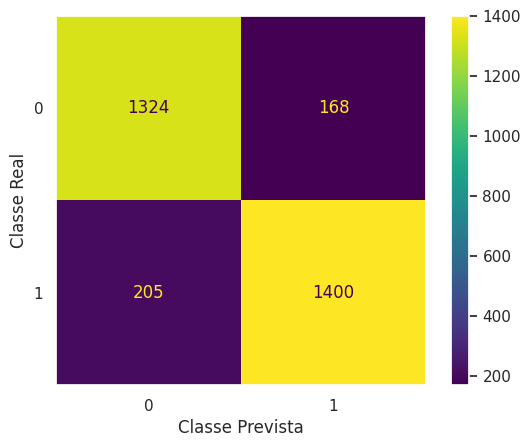

In [111]:
print(f"\nAcurácia Geral (BERTimbau): {accuracy_score(y_test, preds_bert):.4f}\n")
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test, preds_bert))
print("Matriz de Confusão:")
ConfusionMatrixDisplay.from_estimator(modelo_bert, X_test_bert, y_test)
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.grid(False)
plt.show()

### **3.5.5. Salvando o Modelo BERT e o Tokenizer**

In [112]:
# Salvando os embeddings do BERT
np.save('/content/drive/MyDrive/models-pkl/X_train_bert_embeddings.npy', X_train_bert)
np.save('/content/drive/MyDrive/models-pkl/X_test_bert_embeddings.npy', X_test_bert)
print('Embeddings do BERT para treino e teste salvos com sucesso!')

Embeddings do BERT para treino e teste salvos com sucesso!


In [113]:
import joblib
joblib.dump(modelo_bert, '/content/drive/MyDrive/models-pkl/bert_model_nlp_sentimentos.pkl')
joblib.dump(tokenizer, '/content/drive/MyDrive/models-pkl/bert_tokenizer_nlp_sentimentos.pkl')
print('Modelo BERT e Tokenizer salvos com sucesso!')

Modelo BERT e Tokenizer salvos com sucesso!


In [115]:
# Salva o tokenizer e o BERTimbau na pasta local do projeto
tokenizer.save_pretrained('/content/drive/MyDrive/models-pkl')
bert_model.save_pretrained('/content/drive/MyDrive/models-pkl')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [117]:
# 1. Carrega o classificador de ML (arquivo .pkl)
classificador = joblib.load('/content/drive/MyDrive/models-pkl/bert_model_nlp_sentimentos.pkl')

# 2. Carrega o BERTimbau apontando para a PASTA que foi criada no Drive
pasta_bert_drive = '/content/drive/MyDrive/models-pkl/bert_model_nlp_sentimentos'
tokenizer = AutoTokenizer.from_pretrained('/content/drive/MyDrive/models-pkl')
bert_model = AutoModel.from_pretrained('/content/drive/MyDrive/models-pkl')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [142]:
# 2. FUNÇÃO PARA VETORIZAR OS NOVOS TEXTOS
def extrair_embeddings_novos(textos):
    vetores = []
    bert_model.eval()
    with torch.no_grad():
        for texto in textos:
            inputs = tokenizer(str(texto), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            outputs = bert_model(**inputs)
            # Extrai o token [CLS] (índice 0)
            vetor_frase = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
            vetores.append(vetor_frase)
    return np.array(vetores)

In [143]:
def previsao_sentimento_novo(textos_novos):
    # Aplica a vetorização
    text = extrair_embeddings_novos(textos_novos)
    # Faz a predição
    result = classificador.predict(text)
    return result

In [145]:
text = ['O produto chegou antes do prazo e funciona perfeitamente!']
text2 = ['O produto é ruim de péssima qualidade']
result_previsao = previsao_sentimento_novo(text2)
if result_previsao == 1:
    print('O Sentimento do cliente: POSITIVO!')
else:
    print('O Sentimento do cliente: NEGATIVO !')

O Sentimento do cliente: NEGATIVO !


# **<font color='black'> 4. Conclusão e Comparativo de Resultados**

Após testar diferentes abordagens de Processamento de Linguagem Natural, chegamos aos seguintes resultados de acurácia aproximada:

| Técnica | Modelo | Acurácia | Observação Principal |
| :--- | :--- | :---: | :--- |
| **Bag of Words** | Logistic Regression | ~88% | Simples e rápido, mas ignora o contexto das palavras. |<font color='blue'>
|<font color='blue'> **TF-IDF** </font>|<font color='blue'> Logistic Regression </font>|<font color='blue'> **~93%** </font>|<font color='blue'> Excelente equilíbrio entre custo computacional e performance.</font>|
| **Word Embeddings** | Logistic Regression | ~88% | Captura similaridade semântica, mas a média dos vetores pode perder nuances. |
| **BERTimbau** | Logistic Regression | ???? | Estado da arte, entende o contexto profundo, porém exige muito mais poder de processamento. |

### **Análise Final**
1.  **O Vencedor Prático:** O **TF-IDF** apresentou o melhor desempenho neste conjunto de dados específico. Isso ocorre porque, em avaliações de e-commerce, palavras-chave específicas (como "defeito", "amei", "atraso") são indicadores muito fortes de sentimento, e o TF-IDF consegue dar o peso correto a elas.
2.  **Modelos Complexos:** Embora o **BERTimbau** seja tecnicamente superior, sua vantagem competitiva brilha em textos mais longos e complexos. Para frases curtas de avaliações, modelos lineares com TF-IDF costumam ser extremamente robustos.
3.  **Próximos Passos:** Para evoluir este projeto, poderíamos realizar um *Fine-tuning* do BERT ou testar técnicas de balanceamento de classes caso a base de dados fosse mais desproporcional.

# **<font color='blue'> 5. Prevendo novos valores**

## **5.1. Bibliotecas**

In [146]:
!pip install unidecode
nltk.download('rslp')
nltk.download('stopwords')

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [147]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
import nltk
import joblib
from nltk import tokenize
import unidecode
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer


## **5.2. Carregando modelos**

In [148]:
modelo_ml = joblib.load('/content/drive/MyDrive/models-pkl/model_logistic_regressor_nlp_sentimentos.pkl')
tfidf_vectorizer = joblib.load('/content/drive/MyDrive/models-pkl/tfidf_vectorizer_nlp_sentimentos.pkl')

## **5.3. Funções**

In [149]:
palavras_irrelevantes = stopwords.words('portuguese')
token = tokenize.WordPunctTokenizer()
stemmer = RSLPStemmer()

def limpeza_dados(texto):

    # Passo 1: Deixar tudo em letras minusculas
    texto = texto.lower()
    # Passo 2: Remover acentuação
    texto = unidecode.unidecode(texto)
    # Passo 3: Remover caracteres não alpha
    texto = token.tokenize(texto)
    texto = [palavra for palavra in texto if palavra.isalpha()]
    # Passo 4: Remover palavras irrelevantes
    texto = [palavra for palavra in texto if palavra not in palavras_irrelevantes]
    # Passo 5: Reduzir cada uma delas ao seu radical (raiz)
    texto = [stemmer.stem(palavra) for palavra in texto]
    texto = ' '.join(texto)

    return texto

In [150]:
texto_teste = 'Produto de péssima qualidade. Apresentou defeito e não funciona corretamente'
texto_limpo = limpeza_dados(texto_teste)
print(f"Texto Original: {texto_teste}")
print(f"Texto Limpo: {texto_limpo}")

Texto Original: Produto de péssima qualidade. Apresentou defeito e não funciona corretamente
Texto Limpo: produt pess qual apresent defeit nao func corret


In [151]:
def previsao_sentimento(text):
    # Aplica a vetorização
    text = tfidf_vectorizer.transform([text])
    # Faz a predição
    result = modelo_ml.predict(text)
    return result

In [152]:
def formatacao_texto(texto):
    print("Fazendo previsão do sentimento do cliente...")
    print('---'*20)
    print(f"Texto Original: {texto}")

    # Faz a limpeza do texto
    texto_limpo = limpeza_dados(texto)
    print(f"Texto tratado: {texto_limpo}")

    # Faz a previsão do sentimento
    previsao = previsao_sentimento(texto_limpo)

    print('==='*20)
    print("Previsão:")
    if previsao == 1:
        print('O Sentimento do cliente: POSITIVO!')
    else:
        print('O Sentimento do cliente: NEGATIVO !')

## **5.4. Fazendo Previsões de Sentimentos**

In [153]:
texto = 'O produto apresentou defeito. Não recomendo!'
formatacao_texto(texto)

Fazendo previsão do sentimento do cliente...
------------------------------------------------------------
Texto Original: O produto apresentou defeito. Não recomendo!
Texto tratado: produt apresent defeit nao recom
Previsão:
O Sentimento do cliente: NEGATIVO !


In [154]:
texto_2 = 'O produto é mais ou menos. Comprarei novamente!'
formatacao_texto(texto_2)

Fazendo previsão do sentimento do cliente...
------------------------------------------------------------
Texto Original: O produto é mais ou menos. Comprarei novamente!
Texto tratado: produt menos compr nov
Previsão:
O Sentimento do cliente: NEGATIVO !


In [155]:
texto_3 = 'Nesse produto eu dou nota ótimo'
formatacao_texto(texto_3)

Fazendo previsão do sentimento do cliente...
------------------------------------------------------------
Texto Original: Nesse produto eu dou nota ótimo
Texto tratado: ness produt dou not otim
Previsão:
O Sentimento do cliente: POSITIVO!


## **5.5. Demonstração Interativa**

Utilize o campo abaixo para testar o modelo com suas próprias frases. Digite uma avaliação de produto e clique no botão para ver a predição do sentimento.